In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import os
import glob
import re
import ipywidgets as widgets
from IPython.display import display
from scipy.constants import physical_constants, speed_of_light as c
import pynucastro as pyna

#%matplotlib widget

m_u = physical_constants['atomic mass constant energy equivalent in MeV'][0]

In [2]:
SNAP_DIR      = 'Runs/Run_1/snaps'
REACLIB_PATH  = 'Nuclear_Data/Original_files/Reaclib_18_9_20'
MAX_N         = 171   # neutron axis limit
MAX_Z         = 111   # proton axis limit
N_MIN         = 0     # plot only N >= N_MIN
Z_MIN         = 0     # plot only Z >= Z_MIN
CMAP          = 'spring'
VMIN_LOG      = 0     # log10 floor for colorbar  [erg/s/g]
VMAX_LOG      = 9     # log10 ceiling             [erg/s/g]
X_FLOOR       = 1e-30 # abundances below this are not plotted

In [3]:
def parse_snapshot(path):
    """Parse one WinNet snapshot file.

    Returns (time [s], T9 [GK], rho [g/cm^3], df)
    where df has columns [N, Z, A, Y, X].
    """
    with open(path) as fh:
        lines = fh.readlines()

    vals = lines[1].split()
    time = float(vals[0])
    T9   = float(vals[1])
    rho  = float(vals[2])
    data_str = ''.join(lines[3:])
    df = pd.read_csv(
        StringIO(data_str),
        sep=r'\s+', header=None,
        names=['N', 'Z', 'Y', 'X'],
        dtype={'N': int, 'Z': int, 'Y': float, 'X': float},
    )
    df['A'] = df['N'] + df['Z']
    return time, T9, rho, df

In [4]:
rates_Reaclib_winnet = pyna.rates.library.ReacLibLibrary(libfile=REACLIB_PATH)

# Remove duplicate links (keep the one with nonzero derivative)
for pair in rates_Reaclib_winnet.find_duplicate_links():
    if pair[0].eval_deriv(1e9) == 0:
        rates_Reaclib_winnet.remove_rate(pair[1])
    else:
        rates_Reaclib_winnet.remove_rate(pair[0])

filter_beta_minus = pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.Q > 0 and r.reactants[0].Z == r.products[0].Z - 1
)

rates_beta = rates_Reaclib_winnet.filter(filter_beta_minus)
beta_rates_list = rates_beta.get_rates()
print(f"Found {len(beta_rates_list)} beta-minus decay rates")

Found 4861 beta-minus decay rates


In [5]:
# Precompute constant part of heating rate per nucleus:
#   prefactor [erg/s/g per unit X] = lambda * Q * c^2 / m  (x1e4: m^2/s^3 -> cm^2/s^3 = erg/s/g)
# Only X_i changes snapshot to snapshot, so this is computed once.
beta_prefactors = {}  # {(N, Z): prefactor}

for beta_rate in beta_rates_list:
    nuclei = beta_rate.reactants[0]
    Z_i = nuclei.Z
    N_i = nuclei.N
    if not isinstance(nuclei.dm, float):
        continue
    m_i = nuclei.dm + (Z_i + N_i) * m_u
    if m_i <= 0:
        continue
    decay_rate_i = beta_rate.eval(1e9)   # [s^-1] (T-independent for decay)
    Q_i = beta_rate.Q                    # [MeV]
    # erg/s/g per unit X_i  (c in m/s; *1e4 converts m^2/s^3 -> erg/s/g)
    prefactor = decay_rate_i * Q_i * c**2 / m_i * 1e4
    beta_prefactors[(N_i, Z_i)] = prefactor

print(f"Precomputed prefactors for {len(beta_prefactors)} nuclei")

Precomputed prefactors for 1329 nuclei


In [6]:
snap_files = sorted(
    glob.glob(os.path.join(SNAP_DIR, 'snapsh_*.dat')),
    key=lambda p: int(re.search(r'snapsh_(\d+)\.dat', os.path.basename(p)).group(1))
)
print(f"Found {len(snap_files)} snapshots")

Found 5737 snapshots


In [7]:
from matplotlib.colors import ListedColormap
from pynucastro.nucdata import get_all_nuclei

# Stable nuclei (black overlay)
stable_set = set()
for nuc in get_all_nuclei():
    if getattr(nuc, 'tau') == 'stable' and 0 <= nuc.Z <= MAX_Z and 0 <= nuc.N <= MAX_N:
        stable_set.add((nuc.N, nuc.Z))

print(f"Found {len(stable_set)} stable nuclei in chart range")

stable_matrix = np.zeros((MAX_Z + 1, MAX_N + 1))
for (N_i, Z_i) in stable_set:
    stable_matrix[Z_i, N_i] = 1.0

stable_cmap = ListedColormap([(0, 0, 0, 0), 'dimgrey'])  # transparent → black

# All nuclei in the reaclib database (light-grey background layer)
nuclide_set = set()
for rate in rates_Reaclib_winnet.get_rates():
    for nuc in rate.reactants + rate.products:
        if 0 <= nuc.Z <= MAX_Z and 0 <= nuc.N <= MAX_N:
            nuclide_set.add((nuc.N, nuc.Z))

print(f"Found {len(nuclide_set)} unique nuclei in reaclib library")

nuclide_matrix = np.zeros((MAX_Z + 1, MAX_N + 1))
for (N_i, Z_i) in nuclide_set:
    nuclide_matrix[Z_i, N_i] = 1.0

nuclide_cmap = ListedColormap([(0, 0, 0, 0), 'lightgrey'])  # transparent → lightgrey

Found 253 stable nuclei in chart range
Found 6576 unique nuclei in reaclib library


In [8]:
def build_heating_heatmap(df):
    """Build log10(eps_beta) heatmap [erg/s/g] from a snapshot DataFrame.

    NaN        → transparent (light-grey database background shows through)
    log10(eps) → plasma: nucleus has beta heating and X >= X_FLOOR
    """
    matrix = np.full((MAX_Z + 1, MAX_N + 1), np.nan)

    abundance_map = {
        (int(row['N']), int(row['Z'])): row['X']
        for _, row in df.iterrows()
        if row['X'] > X_FLOOR
    }
    for (N_i, Z_i), prefactor in beta_prefactors.items():
        X_i = abundance_map.get((N_i, Z_i), 0.0)
        if X_i <= X_FLOOR:
            continue
        eps_i = prefactor * X_i
        if eps_i > 0 and 0 <= Z_i <= MAX_Z and 0 <= N_i <= MAX_N:
            matrix[Z_i, N_i] = np.log10(eps_i)
    return matrix

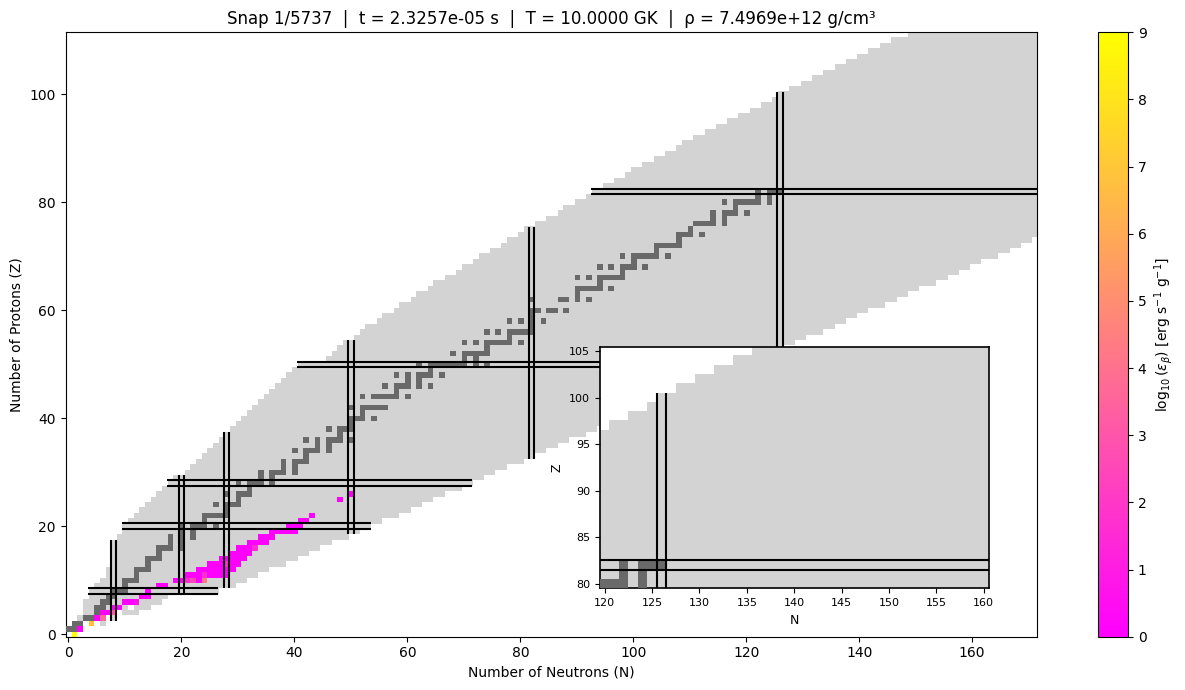

In [9]:
# Inset region bounds
INS_NMIN, INS_NMAX = 120, 160
INS_ZMIN, INS_ZMAX = 80, 105

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlabel("Number of Neutrons (N)")
ax.set_ylabel("Number of Protons (Z)")
ax.set_facecolor('white')

cmap_obj = plt.get_cmap(CMAP).copy()
cmap_obj.set_bad(color=(0, 0, 0, 0))

time0, T9_0, rho0, df0 = parse_snapshot(snap_files[0])
mat0 = build_heating_heatmap(df0)

# Layer 1: light-grey background for all database nuclei
ax.imshow(
    nuclide_matrix[Z_MIN:, N_MIN:], origin='lower', cmap=nuclide_cmap, aspect='auto',
    vmin=0, vmax=1,
    extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
    zorder=1,
)
# Layer 2: beta heating rate
img = ax.imshow(
    mat0[Z_MIN:, N_MIN:], origin='lower', cmap=cmap_obj, aspect='auto',
    vmin=VMIN_LOG, vmax=VMAX_LOG,
    extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
    zorder=2,
)
# Layer 3: stable nuclei overlay (black squares)
ax.imshow(
    stable_matrix[Z_MIN:, N_MIN:], origin='lower', cmap=stable_cmap, aspect='auto',
    vmin=0, vmax=1,
    extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
    zorder=3,
)
# Magic number margins: clipped to the lightgrey (nuclide database) extent
for x_magic in [8, 20, 28, 50, 82, 126]:
    zs = np.where(nuclide_matrix[:, x_magic] == 1)[0]
    if len(zs):
        ax.vlines(x_magic - 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
        ax.vlines(x_magic + 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
for y_magic in [8, 20, 28, 50, 82]:
    ns = np.where(nuclide_matrix[y_magic, :] == 1)[0]
    if len(ns):
        ax.hlines(y_magic - 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
        ax.hlines(y_magic + 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)

cbar = fig.colorbar(img, ax=ax,
                    label=r'$\log_{10}(\varepsilon_\beta)$ [erg s$^{-1}$ g$^{-1}$]')
title = ax.set_title(
    f"Snap 1/{len(snap_files)}  |  "
    f"t = {time0:.4e} s  |  T = {T9_0:.4f} GK  |  ρ = {rho0:.4e} g/cm³"
)

# Inset
axins = ax.inset_axes(
    [0.55, 0.08, 0.40, 0.4],
    xlim=(INS_NMIN - 0.5, INS_NMAX + 0.5),
    ylim=(INS_ZMIN - 0.5, INS_ZMAX + 0.5),
)
subset0 = mat0[INS_ZMIN:INS_ZMAX + 1, INS_NMIN:INS_NMAX + 1]
# Inset layer 1: light grey
axins.imshow(
    nuclide_matrix[INS_ZMIN:INS_ZMAX + 1, INS_NMIN:INS_NMAX + 1],
    origin='lower', cmap=nuclide_cmap, aspect='auto', vmin=0, vmax=1,
    extent=[INS_NMIN - 0.5, INS_NMAX + 0.5, INS_ZMIN - 0.5, INS_ZMAX + 0.5],
    zorder=1,
)
# Inset layer 2: heating rate
img_ins = axins.imshow(
    subset0, origin='lower', cmap=cmap_obj, aspect='auto',
    vmin=VMIN_LOG, vmax=VMAX_LOG,
    extent=[INS_NMIN - 0.5, INS_NMAX + 0.5, INS_ZMIN - 0.5, INS_ZMAX + 0.5],
    zorder=2,
)
# Inset layer 3: stable nuclei
axins.imshow(
    stable_matrix[INS_ZMIN:INS_ZMAX + 1, INS_NMIN:INS_NMAX + 1],
    origin='lower', cmap=stable_cmap, aspect='auto', vmin=0, vmax=1,
    extent=[INS_NMIN - 0.5, INS_NMAX + 0.5, INS_ZMIN - 0.5, INS_ZMAX + 0.5],
    zorder=3,
)
# Magic number margins in inset: clipped to inset region
for x_magic in [8, 20, 28, 50, 82, 126]:
    zs = np.where(nuclide_matrix[INS_ZMIN:INS_ZMAX + 1, x_magic] == 1)[0] + INS_ZMIN
    if len(zs):
        axins.vlines(x_magic - 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
        axins.vlines(x_magic + 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
for y_magic in [8, 20, 28, 50, 82]:
    ns = np.where(nuclide_matrix[y_magic, INS_NMIN:INS_NMAX + 1] == 1)[0] + INS_NMIN
    if len(ns):
        axins.hlines(y_magic - 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)
        axins.hlines(y_magic + 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.5, zorder=4)

axins.set_xlabel('N', fontsize=9)
axins.set_ylabel('Z', fontsize=9)
axins.tick_params(axis='both', labelsize=8)
for spine in axins.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

plt.tight_layout()

In [10]:
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(snap_files) - 1,
    description='Snapshot:',
    continuous_update=False,
    layout=widgets.Layout(width='80%'),
    style={'description_width': '100px'},
)

def update(change):
    idx = change['new']
    time_i, T9_i, rho_i, df_i = parse_snapshot(snap_files[idx])
    mat_i = build_heating_heatmap(df_i)
    img.set_data(mat_i[Z_MIN:, N_MIN:])
    img_ins.set_data(mat_i[INS_ZMIN:INS_ZMAX + 1, INS_NMIN:INS_NMAX + 1])
    title.set_text(
        f"Snap {idx + 1}/{len(snap_files)}  |  "
        f"t = {time_i:.4e} s  |  T = {T9_i:.4f} GK  |  ρ = {rho_i:.4e} g/cm³"
    )
    fig.canvas.draw_idle()

slider.observe(update, names='value')
display(slider)

IntSlider(value=0, continuous_update=False, description='Snapshot:', layout=Layout(width='80%'), max=5736, sty…

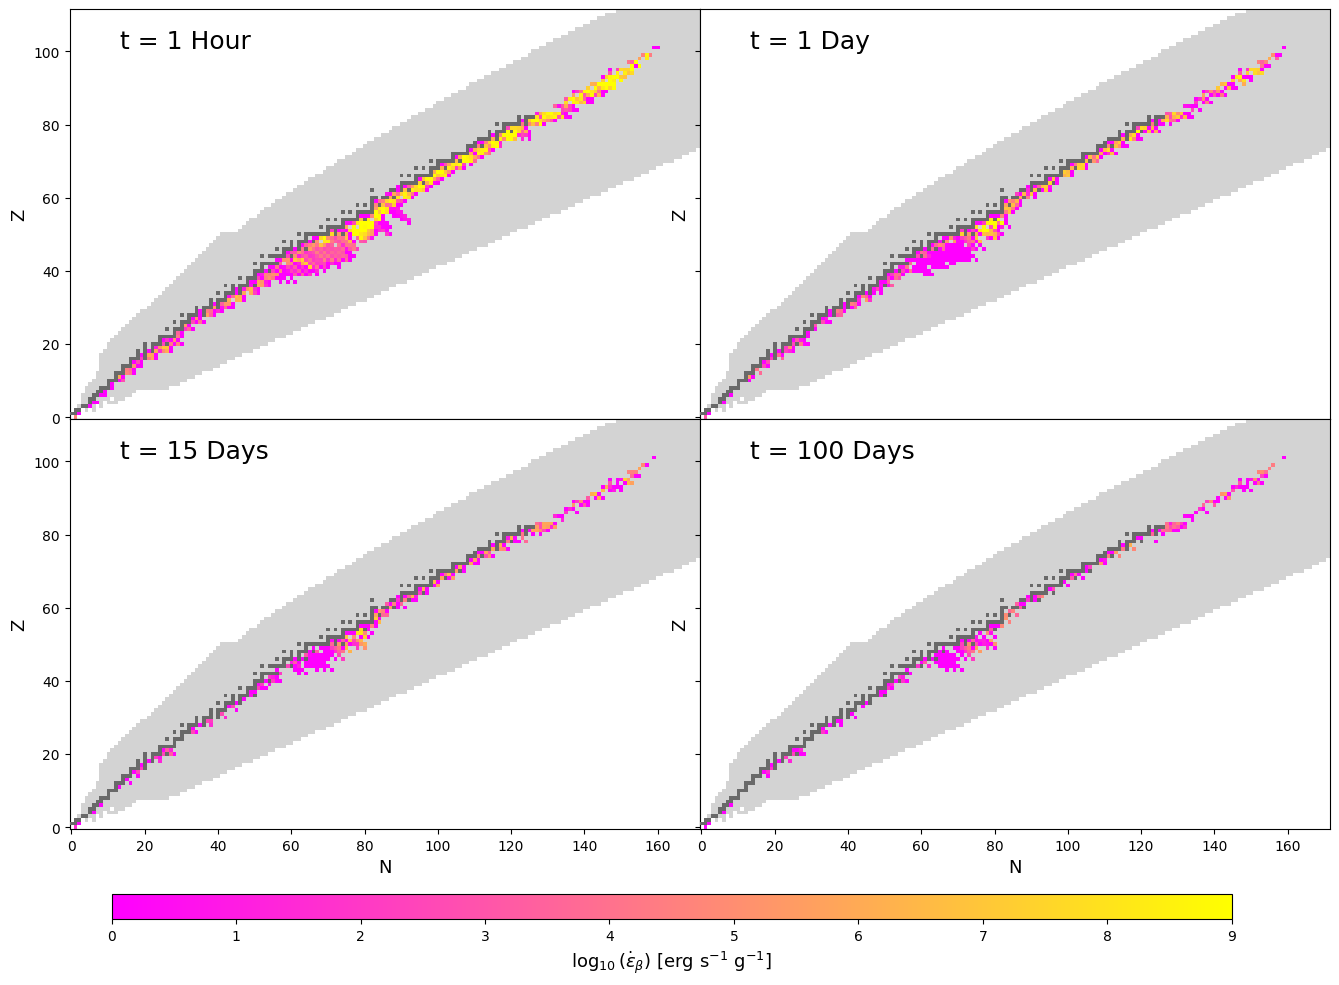

In [12]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

targets = [
    (3600,           "t = 1 Hour"),
    (86400,          "t = 1 Day"),
    (15 * 86400,     "t = 15 Days"),
    (100 * 86400,    "t = 100 Days"),
]

def _snap_time(idx):
    with open(snap_files[idx]) as fh:
        fh.readline()
        return float(fh.readline().split()[0])

def find_snap_for_time(target_s):
    """Binary search for the snapshot index closest to target_s [seconds]."""
    lo, hi = 0, len(snap_files) - 1
    while lo < hi:
        mid = (lo + hi) // 2
        if _snap_time(mid) < target_s:
            lo = mid + 1
        else:
            hi = mid
    if lo > 0 and abs(_snap_time(lo - 1) - target_s) < abs(_snap_time(lo) - target_s):
        return lo - 1
    return lo

cmap_paper = plt.get_cmap(CMAP).copy()
cmap_paper.set_bad(color=(0, 0, 0, 0))

fig_paper, axes = plt.subplots(2, 2, figsize=(14, 10),sharex=True, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0} )

for ax_i, (target_s, label) in zip(axes.flat, targets):
    idx = find_snap_for_time(target_s)
    _, _, _, df_i = parse_snapshot(snap_files[idx])
    mat_i = build_heating_heatmap(df_i)

    ax_i.set_facecolor('white')
    # Layer 1: light-grey database nuclei
    ax_i.imshow(
        nuclide_matrix[Z_MIN:, N_MIN:], origin='lower', cmap=nuclide_cmap, aspect='auto',
        vmin=0, vmax=1,
        extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
        zorder=1,
    )
    # Layer 2: heating rate
    im = ax_i.imshow(
        mat_i[Z_MIN:, N_MIN:], origin='lower', cmap=cmap_paper, aspect='auto',
        vmin=VMIN_LOG, vmax=VMAX_LOG,
        extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
        zorder=2,
    )
    # Layer 3: stable nuclei overlay
    ax_i.imshow(
        stable_matrix[Z_MIN:, N_MIN:], origin='lower', cmap=stable_cmap, aspect='auto',
        vmin=0, vmax=1,
        extent=[N_MIN - 0.5, MAX_N + 0.5, Z_MIN - 0.5, MAX_Z + 0.5],
        zorder=3,
    )
    # Magic number margins: clipped to the lightgrey extent
    #for x_magic in [8, 20, 28, 50, 82, 126]:
    #    zs = np.where(nuclide_matrix[:, x_magic] == 1)[0]
    #    if len(zs):
    #        ax_i.vlines(x_magic - 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.2, zorder=4)
    #        ax_i.vlines(x_magic + 0.5, zs[0] - 0.5, zs[-1] + 0.5, colors='black', linewidths=1.2, zorder=4)
    #for y_magic in [8, 20, 28, 50, 82]:
    #    ns = np.where(nuclide_matrix[y_magic, :] == 1)[0]
    #    if len(ns):
    #        ax_i.hlines(y_magic - 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.2, zorder=4)
    #        ax_i.hlines(y_magic + 0.5, ns[0] - 0.5, ns[-1] + 0.5, colors='black', linewidths=1.2, zorder=4)

    ax_i.set_xlabel("N")
    ax_i.set_ylabel("Z")
    ax_i.text(
    0.08, 0.95, label,
    transform=ax_i.transAxes,
    ha="left",
    va="top",
    fontsize=18)

    

# Horizontal colorbar below all 4 panels
fig_paper.subplots_adjust(left=0.07, right=0.97, top=0.95, bottom=0.13, hspace=0.35, wspace=0.28)
cbar_ax = fig_paper.add_axes([0.1, 0.04, 0.8, 0.025])
fig_paper.colorbar(
    im, cax=cbar_ax, orientation='horizontal',
    label=r'$\log_{10}(\dot\varepsilon_\beta)\ [\mathrm{erg\ s^{-1}\ g^{-1}}]$',
)

fig_paper.savefig("beta_heating_nucharts.pdf", bbox_inches="tight", dpi=300)